In [3408]:
import os
import glob

import optuna
import joblib
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import yaml

# ------------------------------------------------------------
# 1. Load Configuration
# ------------------------------------------------------------
with open('config.yaml', 'r') as file:
    config = yaml.safe_load(file)

# ------------------------------------------------------------
# 2. Configured Paths & Hyperparameters
# ------------------------------------------------------------
AEZ_CSV_PATH = config['paths']['aez_data_dir']
OUTPUT_FOLDER = config['paths']['models_joblib_dir']
PLOTS_DIR = config['paths']['plots_dir']
STATS_FOLDER = config['paths']['stats_dir']

In [3409]:
df = None
AEZ = 19
# PLOTS_DIR = "./plots"

# AEZ_CSV_PATH = "./shc_data/AEZS/AGRI_2023-24/"

PRED_VARIABLE = "OC" # any value from N, P, K, OC
PLOT_SAVE_PATH = os.path.join(os.path.join(PLOTS_DIR, f"AEZ_{AEZ}"), PRED_VARIABLE)

# Bins for each property defined by soil health portal govt.
bin_dict = {
    "N" : [0, 280, 560, np.inf],
    "P" : [0, 10, 25, np.inf],
    "K" : [0, 120, 280, np.inf],
    "OC" : [0.0, 0.50, 0.75, 1.0]
}

os.makedirs(PLOT_SAVE_PATH, exist_ok=True)

In [3410]:
# N_ESTIMATORS = 10
# MAX_DEPTH = 16

N_ESTIMATORS = config['parameters']['rf_n_estimators']
MAX_DEPTH = config['parameters']['rf_max_depth']
X_train, y_train = None, None

In [3411]:
# find optimal params for random forest regressor
# def objective(trial):
#     # Hyperparameters
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 10, 100), #N_ESTIMATORS, #trial.suggest_int('n_estimators', 10, 50),
#         'max_depth': trial.suggest_int('max_depth', 5, 30), #MAX_DEPTH, #trial.suggest_int('max_depth', 5, 20),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
#         'max_features': trial.suggest_float('max_features', 0.3, 1.0),
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     # Train/test split (can also use cross-validation with bin awareness)
#     X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
#     bin_counts = X_train_sub['bin'].value_counts()
#     weights = X_train_sub['bin'].map(lambda b: 10000 * 1.0 / bin_counts[b])
#     model = RandomForestRegressor(**params)
#     model.fit(X_train_sub[selected_feature_names], y_train_sub, weights)

#     y_pred = model.predict(X_val_sub[selected_feature_names])
#     score = r2_score(y_val_sub, y_pred)
    
#     return score

# find optimal params for random forest regressor
def objective(trial):
    # Hyperparameters
    params = {
        'n_estimators': N_ESTIMATORS, #trial.suggest_int('n_estimators', 10, 50),
        'max_depth': MAX_DEPTH, #trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    # Train/test split (can also use cross-validation with bin awareness)
    X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
    bin_counts = X_train_sub['bin'].value_counts()
    
    # weights = X_train_sub['bin'].map(lambda b: 10000 * 1.0 / bin_counts[b])
    # Note the use of np.sqrt()
    # weights = X_train_sub['bin'].map(lambda b: 10000 * 1.0 / np.sqrt(bin_counts[b]))
    # Note the use of np.log()
    # We add 1 to the count (log(n+1)) to avoid taking the log of 1, which is 0.
    weights = X_train_sub['bin'].map(lambda b: 10000 * 1.0 / np.log(bin_counts[b] + 1))
    
    model = RandomForestRegressor(**params)
    model.fit(X_train_sub[selected_feature_names], y_train_sub, weights)

    y_pred = model.predict(X_val_sub[selected_feature_names])
    score = r2_score(y_val_sub, y_pred)
    
    return score

In [3412]:
def smape(y_true, y_pred):
    """
    Compute Symmetric Mean Absolute Percentage Error (sMAPE).
    
    Args:
    y_true (array-like): Actual values.
    y_pred (array-like): Predicted values.
    
    Returns:
    float: sMAPE score (percentage)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_value = np.mean(np.abs(y_true - y_pred) / (denominator+1e-6)) * 100
    return smape_value

In [3413]:
def residual_mae_rmse_colored(y_true, y_pred, bins, save_plots=False, mode='train'):
    df_eval = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred
    })

    # Define bin size and create bins using y_true
    # bin_size = 50
    # bins = np.arange(df_eval['y_true'].min(), df_eval['y_true'].max() + bin_size, bin_size)
    # bins = np.array([0, 150, 200, 300, 400, 500])
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, include_lowest=True)
    
    df_eval['residual'] = df_eval['y_pred'] - df_eval['y_true']
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_eval, x='bin', y='residual')
    plt.xticks(rotation=45)
    plt.xlabel("Bin")
    plt.ylabel("Residual (Prediction - True)")
    plt.title("Residuals by Bin")
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(os.path.join(PLOT_SAVE_PATH, f"{mode}_residual.png"))
    plt.show()
    
    bin_metrics = []
    
    for b, group in df_eval.groupby('bin', observed=False):
        if len(group) < 2:
            continue  # skip tiny bins
        mae = mean_absolute_error(group['y_true'], group['y_pred'])
        rmse = np.sqrt(mean_squared_error(group['y_true'], group['y_pred']))
        bin_metrics.append({'bin': b, 'mae': mae, 'rmse': rmse, 'count': len(group)})
    
    metrics_df = pd.DataFrame(bin_metrics)
    
    # MAE plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=metrics_df, x='bin', y='mae')
    plt.xticks(rotation=45)
    plt.title("MAE per Bin")
    plt.ylabel("MAE")
    plt.xlabel("Bin")
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(os.path.join(PLOT_SAVE_PATH, f"{mode}_mae.png"))
    plt.show()
    
    # RMSE plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=metrics_df, x='bin', y='rmse')
    plt.xticks(rotation=45)
    plt.title("RMSE per Bin")
    plt.ylabel("RMSE")
    plt.xlabel("Bin")
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(os.path.join(PLOT_SAVE_PATH, f"{mode}_rmse.png"))
    plt.show()
    
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df_eval, x='y_true', y='y_pred', hue='bin', palette='tab20', alpha=0.6)
    plt.plot([df_eval['y_true'].min(), df_eval['y_true'].max()], [df_eval['y_true'].min(), df_eval['y_true'].max()], 'k--', label='Ideal')
    plt.xlabel("True Value")
    plt.ylabel("Predicted Value")
    plt.title("True vs Predicted (Colored by Bin)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Nitrogen Bins')
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(os.path.join(PLOT_SAVE_PATH, f"{mode}_bins.png"))
    plt.show()


In [3414]:
def estimation_uncertainity(X_test, y_true, rf, bins, save_plots=False, mode='train'):
    # Assuming rf is your trained RandomForestRegressor model
    # and X_test is your input features
    
    # Combine into a DataFrame
    df_eval = pd.DataFrame({
        'y_true': y_true,
    })

    # Define bin size and create bins using y_true
    bin_size = 50
    # bins = np.arange(df_eval['y_true'].min(), df_eval['y_true'].max() + bin_size, bin_size)
    # bins = np.array([0, 150, 200, 300, 400, 500])
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, include_lowest=True)
    
    # Get predictions from each tree
    all_tree_preds = np.stack([tree.predict(X_test) for tree in rf.estimators_], axis=1)
    
    # Mean prediction
    mean_preds = all_tree_preds.mean(axis=1)
    
    # Uncertainty estimation: Standard deviation across tree predictions
    std_preds = all_tree_preds.std(axis=1)  # this is your uncertainty measure

    df_eval = df_eval.reset_index()
    sorted_indices = np.argsort(y_true)
    y_true_sorted = y_true.iloc[sorted_indices]
    mean_preds_sorted = mean_preds[sorted_indices]
    std_preds_sorted = std_preds[sorted_indices]

    # Plot
    plt.figure(figsize=(10, 6))
    
    # Main prediction line
    plt.scatter(y_true_sorted, mean_preds_sorted, color='orange', label='Prediction', alpha=0.8)
    
    # Uncertainty band (mean ± std dev)
    plt.fill_between(
        y_true_sorted,
        mean_preds_sorted - std_preds_sorted,
        mean_preds_sorted + std_preds_sorted,
        color='blue',
        alpha=0.2,
        label='± 1 Std Dev'
    )
    
    # plt.figure(figsize=(10, 6))
    # plt.errorbar(y_true, mean_preds, yerr=std_preds, fmt='o', alpha=0.5, label='Prediction ± uncertainty')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', label='Ideal')
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Prediction with Uncertainty")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(os.path.join(PLOT_SAVE_PATH, f"{mode}_prediction_uncertainty.png"))
    plt.show()
    
    # Optional: Save to dataframe
    df_eval['y_pred'] = mean_preds
    df_eval['y_std'] = std_preds

    # Bin your data as before
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins)
    
    # Mean uncertainty per bin
    uncertainty_df = df_eval.groupby('bin', observed=False)['y_std'].mean().reset_index()
    uncertainty_df.columns = ['bin', 'uncertainty_std']
    
    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=uncertainty_df, x='bin', y='uncertainty_std', palette='mako', hue='bin', legend=False)
    plt.title("Estimated Prediction Uncertainty per Bin")
    plt.ylabel("Standard Deviation of Tree Predictions")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(os.path.join(PLOT_SAVE_PATH, f"{mode}_uncertainty_barplot.png"))
    plt.show()

In [3415]:
def bin_plots_stats(y_true, y_pred, bins, save_plots=False, mode='train'):
    # Combine into a DataFrame
    df_eval = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred
    })
    
    # Define bin size and create bins using y_true
    # bin_size = 50
    # bins = np.arange(df_eval['y_true'].min(), df_eval['y_true'].max() + bin_size, bin_size)
    # bins = np.array([0, 150, 200, 300, 400, 500])
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, include_lowest=True)
    
    # Group by bins and calculate metrics
    stats = []
    for bin_range, group in df_eval.groupby('bin', observed=False):
        if len(group) < 2:  # skip small groups
            continue
        r2 = r2_score(group['y_true'], group['y_pred'])
        rmse = np.sqrt(mean_squared_error(group['y_true'], group['y_pred']))
        mae = mean_absolute_error(group['y_true'], group['y_pred'])
        smape_value = smape(group['y_true'], group['y_pred'])
        
        stats.append({
            'bin': str(bin_range),
            'count': len(group),
            'rmse': rmse,
            'r2': r2,
            'mae': mae,
            'smape': smape_value
        })
    
        # Visualizing the true vs predicted values
        plt.figure(figsize=(10, 5))
        plt.scatter(group['y_true'], group['y_pred'], color='blue')
        plt.plot([group['y_true'].min(), group['y_true'].max()], [group['y_true'].min(), group['y_true'].max()], 'k--', lw=2)
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.title(f'True vs Predicted Values (Group {bin_range})')
        if save_plots:
            plt.savefig(os.path.join(PLOT_SAVE_PATH, f"{mode}_bin_{str(bin_range)}.png"))
        plt.show()
    
    # Convert to DataFrame
    stats_df = pd.DataFrame(stats)
    # Display or save
    print(stats_df)

In [3416]:
# Add Vegetation Indices (NDVI, EVI, SAVI, NDWI)
def add_indices(df):
    
    # Compute Indices & Add as Columns
    df["NDVI"] = (df["NIR"] - df["RED"]) / (df["NIR"] + df["RED"])
    df["GNDVI"] = (df["NIR"] - df["GREEN"]) / (df["NIR"] + df["GREEN"])
    df["SAVI"] = ((df["NIR"] - df["RED"]) / (df["NIR"] + df["RED"] + 0.5)) * 1.5
    df["NDWI"] = (df["GREEN"] - df["NIR"]) / (df["GREEN"] + df["NIR"])
    df["BI"] = np.sqrt((df["RED"]**2 + df["GREEN"]**2 + df["BLUE"]**2) / 3)
    df["SI"] = (df["RED"] - df["BLUE"]) / (df["RED"] + df["BLUE"])
    df["HI"] = (2 * df["RED"] - df["GREEN"] - df["BLUE"]) / (df["GREEN"] - df["BLUE"])
    df["CI"] = (df["RED"] - df["GREEN"]) / (df["RED"] + df["GREEN"])
    df["RI"] = (df["RED"]**2) / (df["BLUE"] * df["GREEN"]**3)
    df["TGSI"] = (df["SWIR1"] - df["NIR"]) / (df["SWIR1"] + df["NIR"])
    df["NCI"] = (df["SWIR1"] - df["SWIR2"]) / (df["SWIR1"] + df["SWIR2"]) 
    df["EVI"] = (2.5 * (df["NIR"] - df["RED"])) / (df["NIR"] + 6*df["RED"] - 7.5*df["BLUE"] + 1)
    
    return df

## Load the CSV file and apply relevant functions

In [3417]:
df = pd.read_csv(os.path.join(AEZ_CSV_PATH, f"AEZ_{AEZ}.csv"))

df = df.drop(columns=['district', 'village', 'date', 'start_date', 'end_date', 'ae_regcode']) # 'system:index', 
df = add_indices(df)
df = df.drop(columns=['RED', 'BLUE', 'GREEN', 'SWIR1', 'SWIR2', 'NIR'])
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
df[df.select_dtypes(np.float64).columns] = df.select_dtypes(np.float64).astype(np.float32)
df[df.select_dtypes(np.int64).columns] = df.select_dtypes(np.int64).astype(np.int16)

# Print number of rows & columns in merged DataFrame
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
df.head()

Total Rows: 7096, Total Columns: 47


,N,P,K,B,Fe,Zn,Cu,S,OC,pH,...,SAVI,NDWI,BI,SI,HI,CI,RI,TGSI,NCI,EVI
0,248.399994,56.0,275.0,0.64,12.86,0.34,0.90,17.860001,0.49,6.9,...,0.198968,-0.396062,0.077358,0.317658,1.370462,0.039151,288.881134,-0.054461,0.127992,0.187959
1,215.500000,44.0,221.0,0.35,9.92,0.26,0.88,15.040000,0.37,7.4,...,0.198493,-0.385140,0.080071,0.278350,1.308686,0.029986,243.190002,-0.063542,0.139548,0.192104
2,226.399994,61.0,300.0,0.80,13.64,0.26,0.85,26.320000,0.41,7.2,...,0.276683,-0.473388,0.078434,0.211288,1.133538,0.011038,211.681976,-0.095890,0.229921,0.285445
3,237.399994,34.0,363.0,0.30,10.20,0.62,0.62,25.379999,0.45,8.1,...,0.229899,-0.463922,0.069512,0.306546,1.567869,0.054725,376.438538,-0.056107,0.150661,0.219844
4,190.800003,39.0,314.0,1.09,9.98,0.74,0.88,15.980000,0.28,7.4,...,0.261754,-0.463446,0.084734,0.263608,1.546324,0.046857,228.895447,-0.042464,0.207309,0.262136


In [3418]:
# features = df.drop(columns=['B', 'Cu', 'EC', 'Fe', 'K', 'Mn', 'N', 'OC', 'P', 'S', 'Zn', 'pH']).columns
# features = df.drop(columns=['B', 'Cu', 'EC', 'Fe', 'K', 'Mn', 'N', 'OC', 'P', 'S', 'Zn', 'pH', 'latitude', 'longitude']).columns
# features = df.drop(columns=['B', 'Cu', 'EC', 'Fe', 'K', 'Mn', 'N', 'OC', 'P', 'S', 'Zn', 'latitude', 'longitude']).columns
# features = df.drop(columns=['B', 'Cu', 'EC', 'Fe', 'K', 'Mn', 'N', 'OC', 'P', 'S', 'Zn', 'latitude', 'longitude', 'system:index', '.geo']).columns
features = df.drop(columns=['B', 'Cu', 'EC', 'Fe', 'K', 'Mn', 'N', 'OC', 'P', 'S', 'Zn', 'latitude', 'longitude']).columns


features

Index(['pH', 'temp', 'precipitation', 'elevation', 'slope', 'aspect', 'TWI',
       'sand05', 'sand515', 'silt05', 'silt515', 'clay05', 'clay515',
       'NDVI_Kharif', 'NDVI_Rabi', 'NDVI_Zaid', 'NIRv_Kharif', 'NIRv_Rabi',
       'NIRv_Zaid', 'pH_0-5', 'pH_5-15', 'pH_avg', 'NDVI', 'GNDVI', 'SAVI',
       'NDWI', 'BI', 'SI', 'HI', 'CI', 'RI', 'TGSI', 'NCI', 'EVI'],
      dtype='object')

In [3419]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(df[features])
low_variance_cols = [col for col, var in zip(features, selector.variances_) if var < 0.01]
low_variance_cols

['NIRv_Kharif',
 'NIRv_Rabi',
 'NIRv_Zaid',
 'NDVI',
 'GNDVI',
 'SAVI',
 'NDWI',
 'BI',
 'SI',
 'CI',
 'TGSI',
 'NCI',
 'EVI']

### Outliers removed

- Remove top10 from AEZ 15 (nitrogen)
- Remove top5 from AEZ 16 (nitrogen)
- Remove top1 from AEZ 17 (nitrogen)
- Remove top5 from AEZ 18 (phosphorus)

In [3420]:
# df = df[~df[PRED_VARIABLE].isin(df[PRED_VARIABLE].nlargest(5))]

In [3421]:
df[PRED_VARIABLE].describe()

count    7096.000000
mean        0.574249
std         0.221906
min         0.000000
25%         0.420000
50%         0.560000
75%         0.740000
max         1.000000
Name: OC, dtype: float64

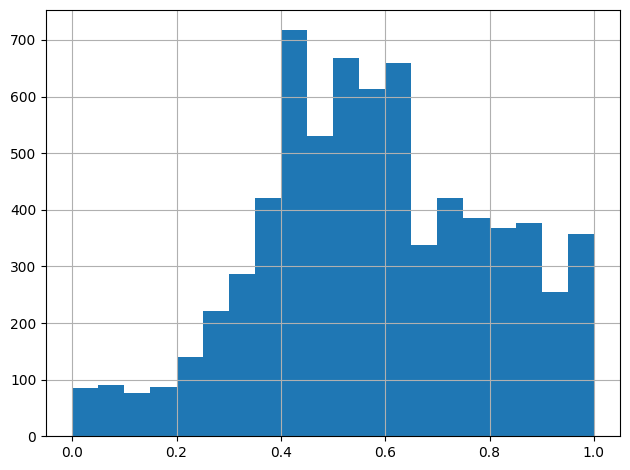

In [3422]:
df[PRED_VARIABLE].hist(bins=20)
plt.tight_layout()
plt.show()

## Apply binning on the data, set `desired_total_bins` to split the data accordingly into finer or coarser bins

target_samples_per_bin=1774
Low region: 2704 points → 2 sub-bins
Mid region: 2685 points → 2 sub-bins
High region: 1707 points → 1 sub-bins
final_bin
0     495
1    2209
2    1650
3    1035
4    1707
Name: count, dtype: int64


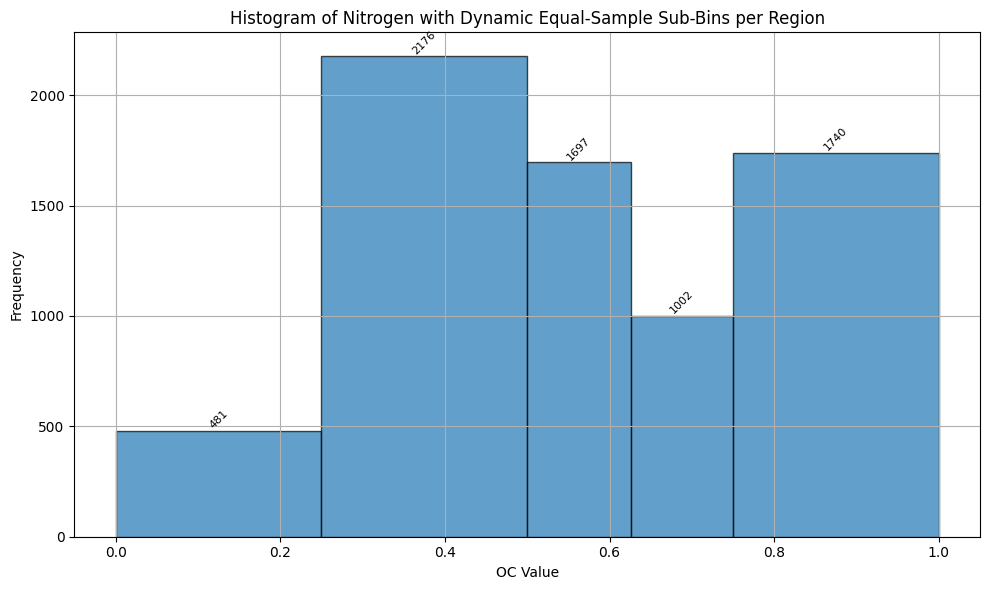

In [3423]:
# Define base bins for NITROGEN: Low (0–280), Mid (280–560), High (560–max)
base_bins = bin_dict[PRED_VARIABLE]
df['base_bin'] = pd.cut(df[PRED_VARIABLE], bins=base_bins, labels=["Low", "Mid", "High"], include_lowest=True)

# Estimate a dynamic target to get ~6 total bins (adjustable between 5–7)
total_points = len(df)
desired_total_bins = 4 # you can randomize between 5–7 if needed
target_samples_per_bin = int(np.ceil(total_points / desired_total_bins))

print(f"{target_samples_per_bin=}")

custom_bins = []

for i, label in enumerate(["Low", "Mid", "High"]):
    subset = df[df['base_bin'] == label]
    if not subset.empty:
        n_points = len(subset)
        sub_bins = max(1, int(np.ceil(n_points / target_samples_per_bin)))
        print(f"{label} region: {n_points} points → {sub_bins} sub-bins")
        edges = np.linspace(subset[PRED_VARIABLE].min(), subset[PRED_VARIABLE].max(), sub_bins + 1)
        # Skip the first edge for all but the first region to avoid overlap
        if i > 0:
            edges = edges[1:]
        custom_bins.extend(edges)

# Sort and ensure uniqueness
custom_bins = sorted(set(custom_bins))
bins = custom_bins
df['bin'] = pd.cut(df[PRED_VARIABLE], bins=bins, include_lowest=True)

# Assign final bins
df['final_bin'] = pd.cut(df[PRED_VARIABLE], bins=custom_bins, labels=False, include_lowest=True)

# Check bin counts
bin_counts = df['final_bin'].value_counts().sort_index()
print(bin_counts)

# Plot histogram
plt.figure(figsize=(10, 6))
counts, bin_edges, _ = plt.hist(df[PRED_VARIABLE], bins=custom_bins, edgecolor='black', alpha=0.7)

# Add count labels above bars
for i in range(len(counts)):
    if counts[i] > 0:
        plt.text((bin_edges[i] + bin_edges[i+1]) / 2, counts[i], str(int(counts[i])),
                 ha='center', va='bottom', fontsize=8, rotation=45)

plt.xlabel(f'{PRED_VARIABLE} Value')
plt.ylabel('Frequency')
plt.title('Histogram of Nitrogen with Dynamic Equal-Sample Sub-Bins per Region')
plt.grid(True)
plt.tight_layout()
# plt.savefig(os.path.join(PLOT_SAVE_PATH, "binning.png"))
plt.show()

In [3424]:
len(counts), len(bins)

(5, 6)

In [3425]:
count_df = pd.DataFrame({"bin": bins[:-1], "count": counts})
count_df

,bin,count
0,0.00000,481.0
1,0.25000,2176.0
2,0.50000,1697.0
3,0.62574,1002.0
4,0.75000,1740.0


In [3426]:
df['bin'].unique()

[(0.25, 0.5], (0.5, 0.626], (0.75, 1.0], (-0.001, 0.25], (0.626, 0.75]]
Categories (5, interval[float64, right]): [(-0.001, 0.25] < (0.25, 0.5] < (0.5, 0.626] < (0.626, 0.75] < (0.75, 1.0]]

## Select the feature names by reviewing the feature importance and remove them iteratively

In [3427]:
selected_feature_names = [
    # 'TWI', 
    # 'aspect', 
    # 'slope', 
    'temp',
    # 'GNDVI',
    # 'NDVI', 
    # 'BI', 
    # 'HI', 
    # 'CI', 
    'SI', 
    'RI',
    # 'elevation', 
    'precipitation', 
    # 'clay05', 
    'sand05',
    'silt05', 
    # 'clay515',
    'sand515',
    # 'silt515',
    'TGSI', 
    'NDVI_Kharif', 'NDVI_Rabi', 'NDVI_Zaid',
    'pH_0-5', 'pH_5-15',
    'NIRv_Kharif', 'NIRv_Rabi', 'NIRv_Zaid'
    # 'NCI',
    # 'SAVI',
    # 'EVI',
    # 'NDWI',
    # 'longitude',
    # 'latitude'
]

y = df[PRED_VARIABLE]
X = df

In [3428]:
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_split=None

In [3429]:
study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=10, timeout=600)
study.optimize(objective, n_trials=26, timeout=1300)

[I 2026-03-11 04:35:04,303] A new study created in memory with name: no-name-2ae48e00-1de6-416e-8f22-69e394514304
[I 2026-03-11 04:35:04,391] Trial 0 finished with value: 0.2142335452214409 and parameters: {'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.8857332607823408}. Best is trial 0 with value: 0.2142335452214409.
[I 2026-03-11 04:35:04,462] Trial 1 finished with value: 0.21845289942648316 and parameters: {'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 0.79791309615157}. Best is trial 1 with value: 0.21845289942648316.
[I 2026-03-11 04:35:04,518] Trial 2 finished with value: 0.2032498143336634 and parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.4818444713368724}. Best is trial 1 with value: 0.21845289942648316.
[I 2026-03-11 04:35:04,615] Trial 3 finished with value: 0.21508765786366246 and parameters: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.9980708609631703}. Best is trial 1 with value: 0.21

In [3430]:
print("Best trial:")
print(f"  R2 score: {study.best_value}")
print(f"  Params: {study.best_trial.params}")

Best trial:
  R2 score: 0.2332789328457534
  Params: {'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 0.47061789041995666}


In [3431]:
MIN_SAMPLES_SPLIT = study.best_trial.params['min_samples_split']
MIN_SAMPLES_LEAF = study.best_trial.params["min_samples_leaf"]
MAX_FEATURES = study.best_trial.params["max_features"]

## 10-Fold Cross-Validation to get the Best Model (Acc. to Test R2 score)

In [3432]:
A = X_train
y = y_train

# Initialize 5-Fold Cross Validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
counter = 0

models = []  # List to store models
r2_scores = [] # list to store r2 scores
scores = []  # List to store all scores
train_test_split_idx = [] # List to store the perfect train-test split

# Perform manual cross-validation
for train_idx, test_idx in kf.split(A):
# for train_idx, test_idx in kf.split(df, df['ae_regcode']):
    X_val_train, X_val_test = A.iloc[train_idx], A.iloc[test_idx]
    y_val_train, y_val_test = y.iloc[train_idx], y.iloc[test_idx]

    bin_counts = X_val_train['bin'].value_counts()
    weights = X_val_train['bin'].map(lambda b: 10000 * 1.0 / bin_counts[b])

    train_test_split_idx.append((train_idx, test_idx))
    
    # Train Random Forest model
    rfr = RandomForestRegressor(
        n_estimators=N_ESTIMATORS, 
        max_depth=MAX_DEPTH, 
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features=MAX_FEATURES,
        random_state=42, 
        n_jobs=-1,
    )
    rfr.fit(X_val_train[selected_feature_names], y_val_train, sample_weight=weights)
    models.append(rfr)

    y_pred = rfr.predict(X_val_test[selected_feature_names]) 
    
    # Evaluate model
    r2 = r2_score(y_val_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_test, y_pred))
    mae = mean_absolute_error(y_val_test, y_pred)
    smape_value = smape(y_val_test, y_pred)

    print(f"K Fold No. {counter+1}")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"sMAPE: {smape_value:.4f}")

    print("=======================")
    
    scores.append({"R2" : r2, "RMSE" : rmse, "MAE" : mae, "sMAPE" : smape_value})
    r2_scores.append(r2)
    counter += 1

# Print performance
print("Cross-validation R² scores:", r2_scores)
print("Mean R² score:", np.mean(r2_scores))

# Retrieve the best model (highest R²)
best_model_idx = np.argmax(r2_scores)
best_model = models[best_model_idx]
best_split = train_test_split_idx[best_model_idx]
print(f"Best model is from fold {best_model_idx+1} with R² = {r2_scores[best_model_idx]:.4f}")

K Fold No. 1
R² Score: 0.2025
RMSE: 0.1950
MAE: 0.1552
sMAPE: 30.0474
K Fold No. 2
R² Score: 0.1698
RMSE: 0.2083
MAE: 0.1617
sMAPE: 30.9278
K Fold No. 3
R² Score: 0.1536
RMSE: 0.2023
MAE: 0.1575
sMAPE: 30.6614
K Fold No. 4
R² Score: 0.2040
RMSE: 0.1926
MAE: 0.1514
sMAPE: 29.3389
K Fold No. 5
R² Score: 0.2057
RMSE: 0.2056
MAE: 0.1631
sMAPE: 32.7291
K Fold No. 6
R² Score: 0.2311
RMSE: 0.1950
MAE: 0.1574
sMAPE: 30.8162
K Fold No. 7
R² Score: 0.1513
RMSE: 0.1903
MAE: 0.1521
sMAPE: 28.4117
K Fold No. 8
R² Score: 0.2270
RMSE: 0.2061
MAE: 0.1625
sMAPE: 32.6936
K Fold No. 9
R² Score: 0.1408
RMSE: 0.2045
MAE: 0.1615
sMAPE: 30.8112
K Fold No. 10
R² Score: 0.1366
RMSE: 0.2107
MAE: 0.1689
sMAPE: 30.9494
Cross-validation R² scores: [0.2025417051908701, 0.1697873649274091, 0.1535863647996052, 0.20404339412620032, 0.20569549708805135, 0.23108806711948815, 0.1513268381548698, 0.22695028318000798, 0.14076927159612618, 0.13664466543340603]
Mean R² score: 0.1822433451616034
Best model is from fold 6 with

In [3433]:
if best_split is not None:
    A = X_train
    train_idx, test_idx = best_split
    X_val_train, X_val_test = A.iloc[train_idx], A.iloc[test_idx]
    y_val_train, y_val_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

### This was a temporary solution to store the experiment results, please replace this with the ML flow code

In [3434]:
# STATS Dataframe
stats_df = pd.DataFrame({"AEZ" : [], "Set" : [], "Property" : [], "R2" : [], "RMSE" : [], "MAE" : [], "sMAPE" : []})

In [3435]:
y_pred = best_model.predict(X_val_train[selected_feature_names])

# Evaluate model performance
r2 = r2_score(y_val_train, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_train, y_pred))
mae = mean_absolute_error(y_val_train, y_pred)
smape_value = smape(y_val_train, y_pred)
print("Model performance on Calibration Train Set")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"sMAPE: {smape_value:.4f}")

new_row = {"AEZ" : AEZ, "Set" : "CAL_TRAIN", "Property" : PRED_VARIABLE, "R2" : r2, "RMSE" : rmse, "MAE" : mae, "sMAPE" : smape_value}
stats_df = pd.concat([stats_df, pd.DataFrame([new_row])], ignore_index=True)

Model performance on Calibration Train Set
R² Score: 0.5443
RMSE: 0.1504
MAE: 0.1186
sMAPE: 23.7062


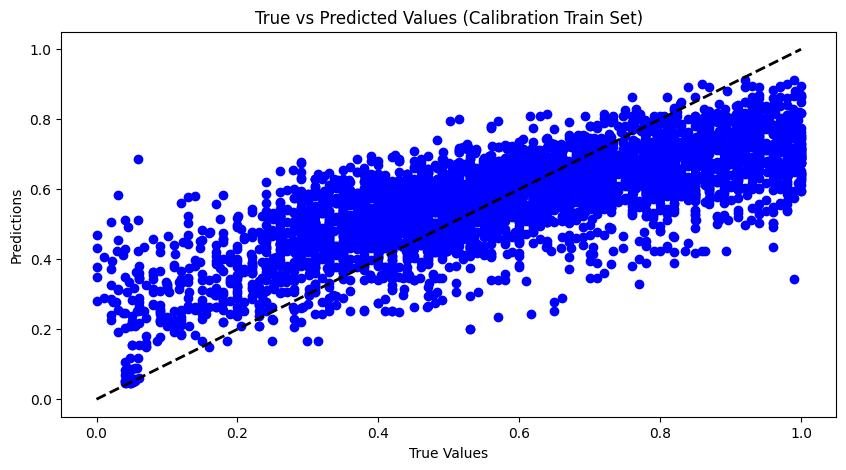

In [3436]:
# Visualizing the true vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_val_train, y_pred, color='blue')
plt.plot([y_val_train.min(), y_val_train.max()], [y_val_train.min(), y_val_train.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values (Calibration Train Set)')
# plt.savefig(os.path.join(PLOT_SAVE_PATH, "cal_train_true_vs_pred.png"))
plt.show()

In [3437]:
# residual_mae_rmse_colored(y_val_train, y_pred, bins, save_plots=False, mode='cal_train')

In [3438]:
y_pred = best_model.predict(X_val_test[selected_feature_names])

# Evaluate model performance
r2 = r2_score(y_val_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_test, y_pred))
mae = mean_absolute_error(y_val_test, y_pred)
smape_value = smape(y_val_test, y_pred)
print("Model performance on Calibration Test Set")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"sMAPE: {smape_value:.4f}")

new_row = {"AEZ" : AEZ, "Set" : "CAL_TEST", "Property" : PRED_VARIABLE, "R2" : r2, "RMSE" : rmse, "MAE" : mae, "sMAPE" : smape_value}
stats_df = pd.concat([stats_df, pd.DataFrame([new_row])], ignore_index=True)

Model performance on Calibration Test Set
R² Score: 0.2311
RMSE: 0.1950
MAE: 0.1574
sMAPE: 30.8162


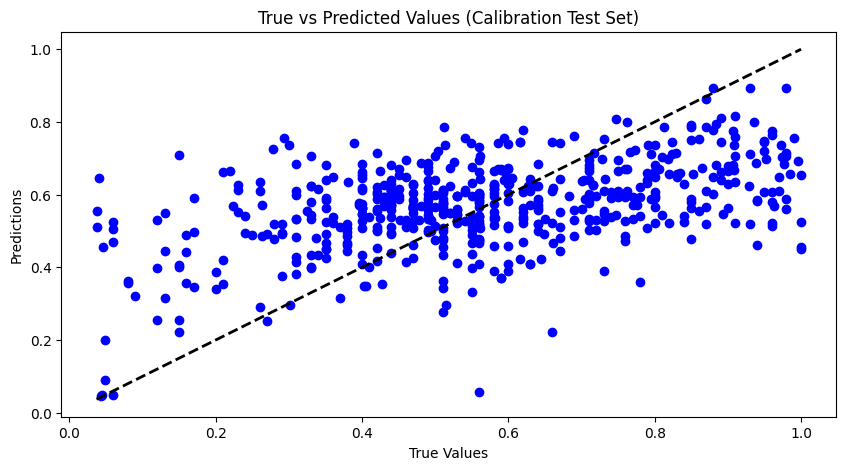

In [3439]:
# Visualizing the true vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_val_test, y_pred, color='blue')
plt.plot([y_val_test.min(), y_val_test.max()], [y_val_test.min(), y_val_test.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values (Calibration Test Set)')
# plt.savefig(os.path.join(PLOT_SAVE_PATH, "cal_test_true_vs_pred.png"))
plt.show()

In [3440]:
# residual_mae_rmse_colored(y_val_test, y_pred, bins, save_plots=False, mode='cal_test')

In [3441]:
y_pred = best_model.predict(X_test[selected_feature_names])

# Evaluate model performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
smape_value = smape(y_test, y_pred)
print("Model performance on Test Set")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"sMAPE: {smape_value:.4f}")

new_row = {"AEZ" : AEZ, "Set" : "TEST", "Property" : PRED_VARIABLE, "R2" : r2, "RMSE" : rmse, "MAE" : mae, "sMAPE" : smape_value}
stats_df = pd.concat([stats_df, pd.DataFrame([new_row])], ignore_index=True)

Model performance on Test Set
R² Score: 0.1887
RMSE: 0.1967
MAE: 0.1555
sMAPE: 29.4108


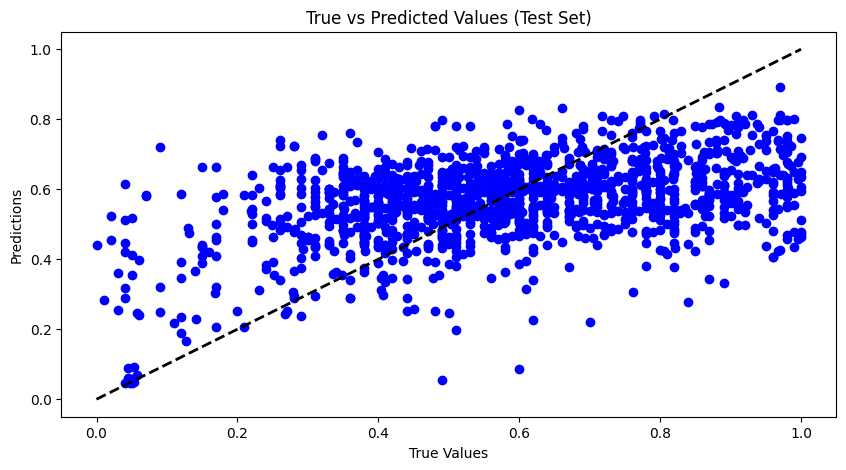

In [3442]:
# Visualizing the true vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values (Test Set)')
# plt.savefig(os.path.join(PLOT_SAVE_PATH, "test_true_vs_pred.png"))
plt.show()

In [3443]:
# residual_mae_rmse_colored(y_test, y_pred, bins, save_plots=False, mode='test')

## Review feature importance to remove less important features

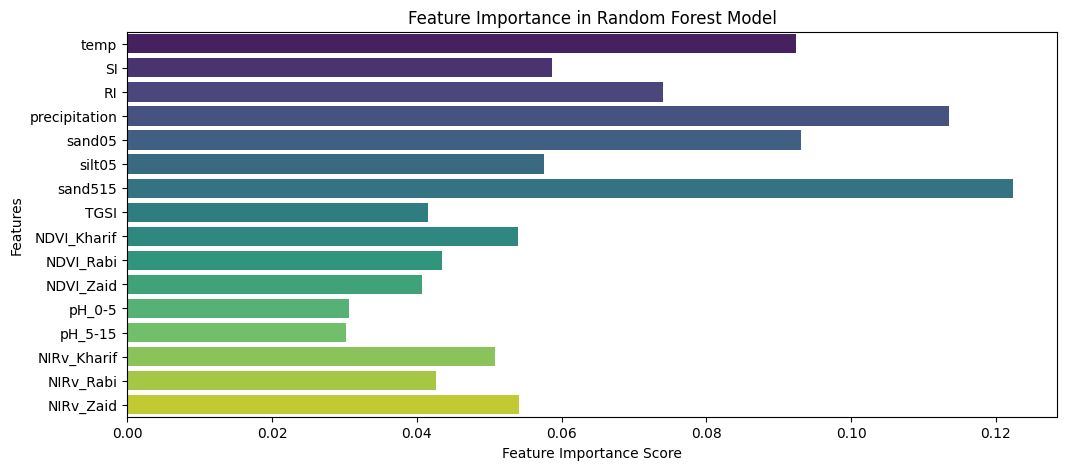

In [3444]:
# Feature importance plot
plt.figure(figsize=(12, 5))
importance = best_model.feature_importances_
feature_names = selected_feature_names
sns.barplot(x=importance, y=feature_names, palette="viridis", hue=feature_names)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest Model")
plt.savefig(os.path.join(PLOT_SAVE_PATH, "feature_importance.png"))
plt.show()

In [3445]:
# Create a DataFrame for Sorting
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort in Descending Order
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Print Sorted Feature Importances
print(feature_importance_df)

          Feature  Importance
6         sand515    0.122346
3   precipitation    0.113503
4          sand05    0.093149
0            temp    0.092444
2              RI    0.073964
1              SI    0.058741
5          silt05    0.057574
15      NIRv_Zaid    0.054101
8     NDVI_Kharif    0.054053
13    NIRv_Kharif    0.050865
9       NDVI_Rabi    0.043468
14      NIRv_Rabi    0.042643
7            TGSI    0.041524
10      NDVI_Zaid    0.040769
11         pH_0-5    0.030681
12        pH_5-15    0.030176


In [3446]:
cross_val_df = pd.DataFrame(scores)
cross_val_df

,R2,RMSE,MAE,sMAPE
0,0.202542,0.195006,0.155184,30.047408
1,0.169787,0.208256,0.161703,30.927848
2,0.153586,0.202264,0.157484,30.661382
3,0.204043,0.192622,0.151432,29.338904
4,0.205695,0.205558,0.163137,32.729107
5,0.231088,0.195031,0.157359,30.816227
6,0.151327,0.190336,0.152137,28.411680
7,0.226950,0.206123,0.162531,32.693551
8,0.140769,0.204503,0.161489,30.811247
9,0.136645,0.210660,0.168881,30.949389


In [3447]:
cross_val_mean = cross_val_df.mean()
new_row = {"AEZ" : AEZ, "Set" : "CROSS_VAL_MEAN", "Property" : PRED_VARIABLE, "R2" : cross_val_mean["R2"], "RMSE" : cross_val_mean["RMSE"], "MAE" : cross_val_mean["MAE"], "sMAPE" : cross_val_mean["sMAPE"]}
stats_df = pd.concat([stats_df, pd.DataFrame([new_row])], ignore_index=True)
cross_val_mean

R2        0.182243
RMSE      0.201036
MAE       0.159134
sMAPE    30.738674
dtype: float64

In [3448]:
# Save the model as joblib file
# OUTPUT_FOLDER = "./rfr_joblib"
file_name = f"rfr_model_{str(datetime.datetime.today().date())}_AEZ_{AEZ}_{PRED_VARIABLE}.joblib"
model_path = os.path.join(OUTPUT_FOLDER, file_name)
joblib.dump(best_model, model_path)

['./experiments/experiment_5_ndvi_pH_NIRv_LULC/rfr_joblib/rfr_model_2026-03-11_AEZ_19_OC.joblib']

In [3449]:
# STATS_FOLDER = "./stats"
STATS_PATH = os.path.join(STATS_FOLDER, f"AEZ_{AEZ}")
os.makedirs(STATS_PATH, exist_ok=True)

SAVE_CSV_PATH = os.path.join(STATS_PATH, f"stats_{PRED_VARIABLE}.csv")

In [3450]:
stats_df

,AEZ,Set,Property,R2,RMSE,MAE,sMAPE
0,19.0,CAL_TRAIN,OC,0.544267,0.150378,0.118646,23.706152
1,19.0,CAL_TEST,OC,0.231088,0.195031,0.157359,30.816227
2,19.0,TEST,OC,0.188708,0.196705,0.155453,29.410814
3,19.0,CROSS_VAL_MEAN,OC,0.182243,0.201036,0.159134,30.738674


In [3451]:
stats_df.to_csv(SAVE_CSV_PATH, index=False)